### Set up Kaggle API and Download Dataset


In [1]:
import os

# Create a .kaggle directory if it doesn't exist
!mkdir -p ~/.kaggle

# Move the kaggle.json file to the .kaggle directory
# Make sure you have uploaded kaggle.json to your Colab session files
!mv kaggle.json ~/.kaggle/

# Set permissions for the kaggle.json file
!chmod 600 ~/.kaggle/kaggle.json

print("Kaggle API key setup complete!")

mv: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Kaggle API key setup complete!


In [2]:
# Download the dataset
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia

print("Dataset downloaded!")

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [00:10<00:00, 229MB/s]

Dataset downloaded!


The dataset is downloaded as a `.zip` file. We need to unzip it to access the image files.

In [3]:
import zipfile

# Define the path to the downloaded zip file
zip_file_path = 'chest-xray-pneumonia.zip'

# Define the directory to extract the files into
extraction_path = 'chest_xray_dataset'

# Create the extraction directory if it doesn't exist
os.makedirs(extraction_path, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extraction_path)

print(f"Dataset unzipped to '{extraction_path}'")

# Verify the contents of the extracted directory
print("Contents of extracted directory:")
!ls -F {extraction_path}/chest_xray

Dataset unzipped to 'chest_xray_dataset'
Contents of extracted directory:
chest_xray/  __MACOSX/	test/  train/  val/


### Data Preprocessing and Augmentation

Next, we'll set up data generators for the training, validation, and test sets. This will involve resizing images, normalizing pixel values and applying data augmentation to the training set to help prevent overfitting.

In [12]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define image dimensions and batch size
IMAGE_SIZE = (150, 150)
BATCH_SIZE = 32

# Define paths to the dataset folders
base_dir = os.path.join(extraction_path, 'chest_xray', 'chest_xray') # Corrected path after unzipping
train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'val')
test_dir = os.path.join(base_dir, 'test')

# Data Augmentation and Rescaling for Training Data - ENHANCED
train_datagen = ImageDataGenerator(
    rescale=1./255, # Normalize pixel values to [0, 1]
    rotation_range=20, # Rotate images by up to 20 degrees
    width_shift_range=0.1, # Shift images horizontally by up to 10% of the width
    height_shift_range=0.1, # Shift images vertically by up to 10% of the height
    brightness_range=[0.8, 1.2], # Adjust brightness
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest' # Fill new pixels created by transformations
)

# Rescaling for Validation and Test Data (no augmentation)
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

# Create data generators
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary' # 'binary' for 2 classes (Pneumonia/Normal)
)

validation_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False # Keep data in order for evaluation
)

print("Data generators created successfully with enhanced augmentation.")
print(f"Training images: {train_generator.samples}")
print(f"Validation images: {validation_generator.samples}")
print(f"Test images: {test_generator.samples}")

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Data generators created successfully with enhanced augmentation.
Training images: 5216
Validation images: 16
Test images: 624


### Build the CNN Model

Now, we will define the Convolutional Neural Network (CNN) architecture. We will use `tf.keras.Sequential` to stack layers, including convolutional layers (`Conv2D`), pooling layers (`MaxPooling2D`) and dense layers (`Dense`). Dropout will be used to prevent overfitting.

In [5]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3)),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dropout(0.5), # Dropout for regularization
    Dense(512, activation='relu'),
    Dense(1, activation='sigmoid') # Sigmoid for binary classification
])

model.summary()

print("CNN model built successfully.")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 15, 15, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     3,211,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,453,121 (13.17 MB)

 Trainable params: 3,453,121 (13.17 MB)

 Non-trainable params: 0 (0.00 B)

CNN model built successfully.


### Compile and Train the Model

After defining the model, we need to compile it by specifying an optimizer, a loss function and metrics. Then, we will train the model using the `fit` method with the training and validation generators.

In [13]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Compile the model
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Callbacks to prevent overfitting and improve training stability
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=0.00001)

print("Retraining model with enhanced data augmentation...")
# Train the model
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    epochs=25, # You can adjust the number of epochs
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // BATCH_SIZE,
    callbacks=[early_stopping, reduce_lr]
)

print("Model retraining complete.")

Retraining model with enhanced data augmentation...
Epoch 1/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 330s 2s/step - accuracy: 0.9016 - loss: 0.2403 - val_accuracy: 0.8125 - val_loss: 0.3042 - learning_rate: 0.0010
Epoch 2/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 328s 2s/step - accuracy: 0.9118 - loss: 0.2130 - val_accuracy: 0.7500 - val_loss: 0.6180 - learning_rate: 0.0010
Epoch 3/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 326s 2s/step - accuracy: 0.9208 - loss: 0.1968 - val_accuracy: 0.6875 - val_loss: 0.8312 - learning_rate: 0.0010
Epoch 4/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 389s 2s/step - accuracy: 0.9256 - loss: 0.1861 - val_accuracy: 0.6875 - val_loss: 0.8124 - learning_rate: 0.0010
Epoch 5/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 336s 2s/step - accuracy: 0.9379 - loss: 0.1587 - val_accuracy: 0.7500 - val_loss: 0.4771 - learning_rate: 2.0000e-04
Epoch 6/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 372s 2s/step - accuracy: 0.9402 - loss: 0.1549 - val_accuracy: 0.6875 - val_loss: 0.6051 - learning_rate: 2.0000e-04
Model retraining compl

### Addressing Class Imbalance with Class Weighting

To further improve the model and potentially reduce validation loss, we will address the class imbalance present in our dataset. The `train_generator` shows:
*   **Pneumonia:** 3875 images
*   **Normal:** 1341 images

This imbalance can cause the model to be biased towards the majority class. We will calculate class weights and apply them during training to give more importance to the minority class.

In [16]:
from sklearn.utils import class_weight
import numpy as np

# Get class labels from the training generator
labels = train_generator.classes

# Count the occurrences of each class
class_counts = np.bincount(labels)

# Calculate the total number of samples
total_samples = len(labels)

# Calculate class weights
# Formula: total_samples / (number_of_classes * count_of_class)
num_classes = len(np.unique(labels))

class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)

class_weight_dict = dict(enumerate(class_weights))

print(f"Original class distribution: {dict(zip(train_generator.class_indices.keys(), class_counts))}")
print(f"Calculated class weights: {class_weight_dict}")

Original class distribution: {'NORMAL': np.int64(1341), 'PNEUMONIA': np.int64(3875)}
Calculated class weights: {0: np.float64(1.9448173005219984), 1: np.float64(0.6730322580645162)}


Now, we will retrain the model using these calculated `class_weight` to mitigate the effect of class imbalance.

In [ ]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Recompile the model to reset optimizer state (important when retraining)
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Callbacks to prevent overfitting and improve training stability
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=0.00001)

print("Retraining model with enhanced data augmentation and class weights...")
# Train the model with class weights
history_weighted = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    epochs=25, # You can adjust the number of epochs
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // BATCH_SIZE,
    callbacks=[early_stopping, reduce_lr],
    class_weight=class_weight_dict # Apply the calculated class weights
)

print("Model retraining with class weights complete.")

Retraining model with enhanced data augmentation and class weights...
Epoch 1/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 339s 2s/step - accuracy: 0.8909 - loss: 0.2528 - val_accuracy: 0.8125 - val_loss: 0.4207 - learning_rate: 0.0010
Epoch 2/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 371s 2s/step - accuracy: 0.9047 - loss: 0.2301 - val_accuracy: 0.9375 - val_loss: 0.3052 - learning_rate: 0.0010
Epoch 3/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 324s 2s/step - accuracy: 0.9122 - loss: 0.2188 - val_accuracy: 0.6875 - val_loss: 0.7630 - learning_rate: 0.0010
Epoch 4/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 383s 2s/step - accuracy: 0.9132 - loss: 0.2120 - val_accuracy: 0.8750 - val_loss: 0.2357 - learning_rate: 0.0010
Epoch 5/25
144/163 ━━━━━━━━━━━━━━━━━━━━ 38s 2s/step - accuracy: 0.8996 - loss: 0.2421

In [15]:
# Evaluate the model on the test data using the test_generator
loss, accuracy = model.evaluate(test_generator, steps=test_generator.samples // BATCH_SIZE)

print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

19/19 ━━━━━━━━━━━━━━━━━━━━ 14s 684ms/step - accuracy: 0.8997 - loss: 0.2917
Test Loss: 0.2917
Test Accuracy: 0.8997


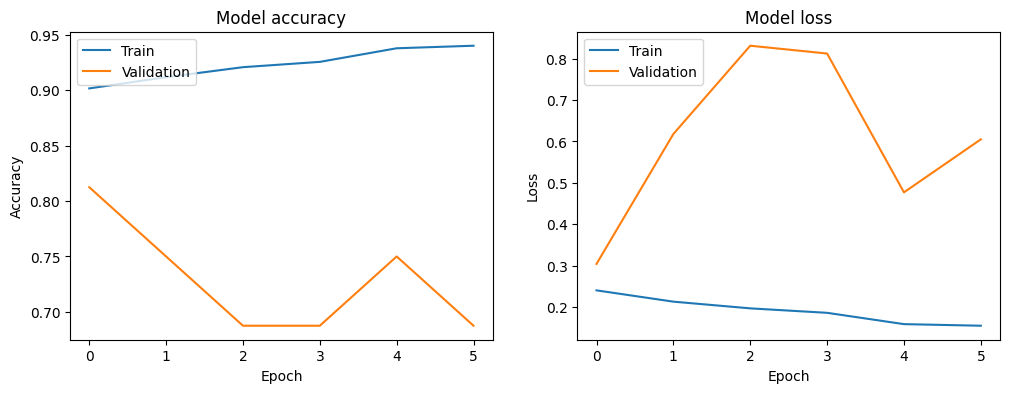

In [14]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

***Model Accuracy Interpretation :***
The model learns the training data very well.
However, validation accuracy does not improve consistently.
The large gap between training and validation accuracy indicates:
Overfitting

The model is memorizing training data rather than generalizing to unseen data.

***Model Loss Interpretation:***
Training performance improves
Validation performance worsens over time
Rising validation loss while training loss decreases is a classic sign of:
Severe Overfitting

### Evaluate the Model

Finally, we will evaluate the trained model on the unseen test dataset to determine its generalization performance.

In [7]:
# Evaluate the model on the test data
loss, accuracy = model.evaluate(test_generator, steps=test_generator.samples // BATCH_SIZE)

print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

19/19 ━━━━━━━━━━━━━━━━━━━━ 16s 823ms/step - accuracy: 0.8980 - loss: 0.2686
Test Loss: 0.2686
Test Accuracy: 0.8980


### Visualize Training History

It's useful to visualize the training history (accuracy and loss over epochs) to understand model performance and identify potential overfitting.

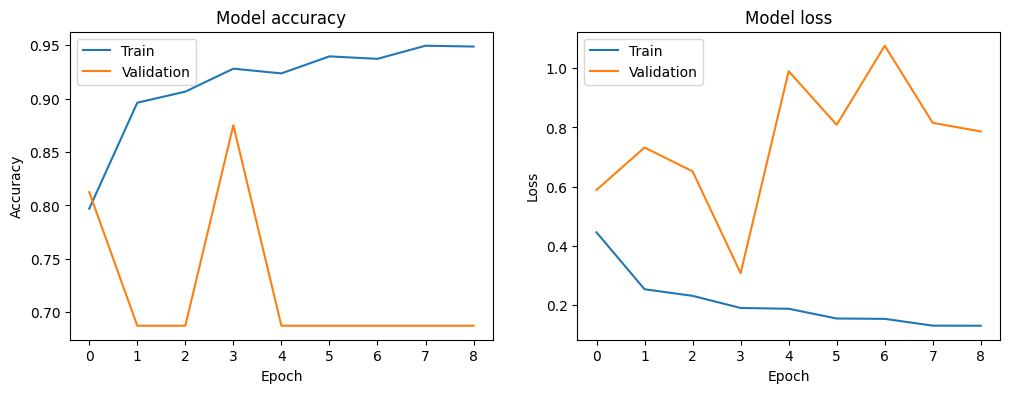

In [8]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

### Make Predictions

Here's how you can make predictions on new images using your trained model.

In [9]:
import numpy as np
from tensorflow.keras.preprocessing import image

def predict_image(img_path):
    img = image.load_img(img_path, target_size=IMAGE_SIZE)
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0 # Add batch dimension and normalize
    prediction = model.predict(img_array)

    if prediction[0] > 0.5:
        return 'Pneumonia', prediction[0]
    else:
        return 'Normal', prediction[0]

# Example usage (you would need a path to an image file)
# For demonstration, let's pick one image from the test set

# Get one image path from the test generator
# Make sure to run the test_generator cell again if you modified it after initial creation
img_paths = test_generator.filepaths

# Pick a normal image
normal_img_path = ''
for path, label_idx in zip(test_generator.filepaths, test_generator.labels):
    if label_idx == 0: # 0 typically represents 'NORMAL'
        normal_img_path = path
        break

# Pick a pneumonia image
pneumonia_img_path = ''
for path, label_idx in zip(test_generator.filepaths, test_generator.labels):
    if label_idx == 1: # 1 typically represents 'PNEUMONIA'
        pneumonia_img_path = path
        break

if normal_img_path:
    class_name, prob = predict_image(normal_img_path)
    print(f"Prediction for normal image: {class_name} (Probability: {prob[0]:.4f})")
else:
    print("Could not find a normal image in the test set for prediction example.")

if pneumonia_img_path:
    class_name, prob = predict_image(pneumonia_img_path)
    print(f"Prediction for pneumonia image: {class_name} (Probability: {prob[0]:.4f})")
else:
    print("Could not find a pneumonia image in the test set for prediction example.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step
Prediction for normal image: Normal (Probability: 0.0240)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
Prediction for pneumonia image: Pneumonia (Probability: 0.6752)


### Confusion Matrix

A confusion matrix provides a detailed breakdown of correct and incorrect classifications for each class, showing where the model might be making mistakes.

20/20 ━━━━━━━━━━━━━━━━━━━━ 15s 666ms/step


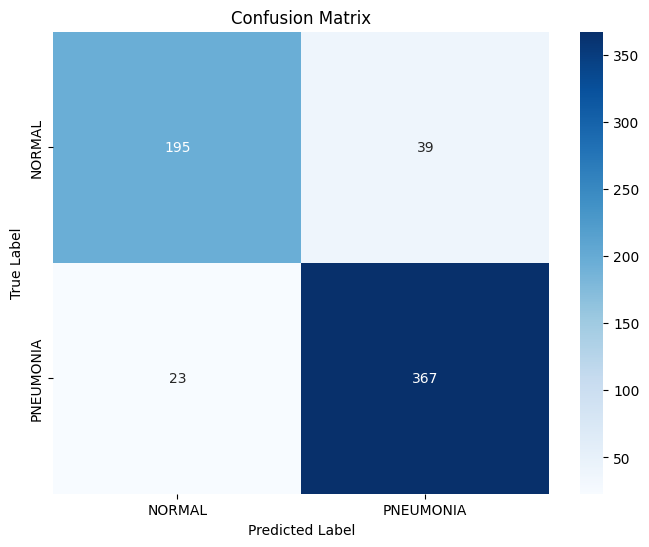

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.89      0.83      0.86       234
   PNEUMONIA       0.90      0.94      0.92       390

    accuracy                           0.90       624
   macro avg       0.90      0.89      0.89       624
weighted avg       0.90      0.90      0.90       624



In [10]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Get true labels
y_true = test_generator.classes

# Get predicted probabilities
y_pred_prob = model.predict(test_generator)

# Convert probabilities to binary predictions (0 or 1) using a threshold of 0.5
y_pred = (y_pred_prob > 0.5).astype(int)

# Generate confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Get class labels from the generator
class_labels = list(test_generator.class_indices.keys())

# Plotting the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# You can also print classification report for more metrics
from sklearn.metrics import classification_report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_labels))

### ROC Curve and AUC Score

The ROC curve illustrates the diagnostic ability of a binary classifier system as its discrimination threshold is varied. The Area Under the ROC Curve (AUC) provides an aggregate measure of performance across all possible classification thresholds. An AUC of 1 represents a perfect classifier, while an AUC of 0.5 represents a classifier with no discriminative power (like random guessing).

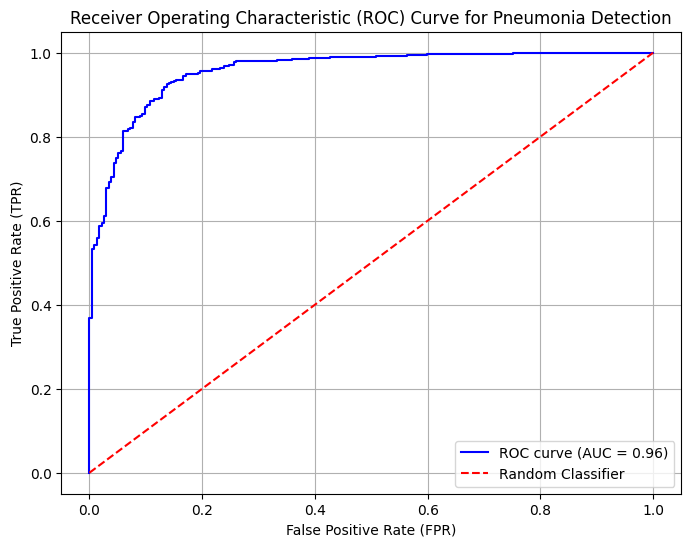

AUC Score for Pneumonia Detection: 0.9569


In [11]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

def plot_roc_curve(y_true, y_pred_prob, class_label='Pneumonia'):
    """
    Calculates and plots the ROC curve, and displays the AUC score.

    Args:
        y_true (array-like): True binary labels (0 or 1).
        y_pred_prob (array-like): Predicted probabilities for the positive class.
        class_label (str): The label for the positive class (e.g., 'Pneumonia').
    """
    # Calculate ROC curve
    fpr, tpr, thresholds = roc_curve(y_true, y_pred_prob)

    # Calculate AUC score
    auc_score = roc_auc_score(y_true, y_pred_prob)

    # Plot ROC curve
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {auc_score:.2f})')
    plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Classifier')
    plt.xlabel('False Positive Rate (FPR)')
    plt.ylabel('True Positive Rate (TPR)')
    plt.title(f'Receiver Operating Characteristic (ROC) Curve for {class_label} Detection')
    plt.legend()
    plt.grid(True)
    plt.show()

    print(f"AUC Score for {class_label} Detection: {auc_score:.4f}")

# Call the function with our test data
# y_true and y_pred_prob were already calculated for the confusion matrix
plot_roc_curve(y_true, y_pred_prob, class_label='Pneumonia')

**Model Architecture and Training Decisions**

The approach to detecting pneumonia from chest X-ray images involved developing and training a Convolutional Neural Network (CNN) using TensorFlow and Keras. The model's architecture and training strategy were carefully designed to maximize accuracy and minimize overfitting.

1. Model Architecture:

The CNN was constructed as a sequential model, comprising several convolutional and pooling layers, followed by fully connected dense layers. The key components include:

Input Layer: Images were resized to 150x150 pixels with 3 color channels (RGB) before being fed into the network.
Convolutional Blocks: The model utilizes four blocks, each consisting of a Conv2D layer followed by a MaxPooling2D layer. This design allows the network to progressively extract hierarchical features from the input images while reducing spatial dimensions.
Conv2D Layers: These layers use 3x3 kernels with a default stride of (1,1) and 'valid' padding. The number of filters progressively increases (32, 64, 128, 128) in successive blocks, enabling the capture of increasingly complex patterns.
MaxPooling2D Layers: These layers use 2x2 pooling windows with a default stride of (2,2), effectively downsampling the feature maps and making the model more robust to minor shifts in input.
Activation Function: The Rectified Linear Unit (ReLU) activation function was applied after each convolutional layer, introducing non-linearity to the model.
Flatten Layer: After the final pooling layer, a Flatten layer converts the 2D feature maps into a 1D vector, preparing the data for the fully connected layers.
Dense Layers:
A hidden Dense layer with 512 units, also using ReLU activation.
An output Dense layer with 1 unit and a sigmoid activation function for binary classification (outputting a probability between 0 and 1 for the 'Pneumonia' class).
2. Training Configuration:

Optimizer: The Adam optimizer was chosen due to its efficiency and good performance across various deep learning tasks. An initial learning_rate of 0.001 was set.
Loss Function: Binary Crossentropy was used as the loss function, which is standard for binary classification problems.
Evaluation Metric: The model's performance was primarily evaluated using accuracy.
Epochs: The training was configured for a maximum of 25 epochs, though early stopping often truncated this before completion.
3. Strategies to Avoid Overfitting:

Overfitting is a common challenge in deep learning, especially with image data. Several techniques were implemented to enhance the model's generalization capabilities:

Data Augmentation: The ImageDataGenerator was extensively used for the training set to artificially expand the dataset. Techniques included shear_range=0.2, zoom_range=0.2, and horizontal_flip=True. This helps the model learn more robust features by presenting varied orientations and distortions of the original images.
Dropout Regularization: A Dropout layer with a rate of 0.5 was strategically placed before the final dense layers. This randomly sets a fraction of input units to 0 at each update during training, which helps prevent complex co-adaptations on training data.
Early Stopping: The EarlyStopping callback was configured to monitor the validation loss ('val_loss') with a patience of 5 epochs. If the validation loss did not improve for 5 consecutive epochs, training was halted, and the model weights from the epoch with the best validation loss were restored.
Learning Rate Scheduling: The ReduceLROnPlateau callback was used to dynamically adjust the learning rate. If the val_loss did not improve for 3 consecutive epochs, the learning rate was reduced by a factor of 0.2, down to a min_lr of 0.00001. This allows the model to escape local minima and converge more effectively.
4. Data Utilization:

Training Set: Used for updating model weights during backpropagation.
Validation Set: Used to monitor model performance during training, guide hyperparameter tuning (via callbacks), and detect overfitting.
Test Set: Reserved for the final, unbiased evaluation of the model's generalization ability after all training and hyperparameter tuning were complete. The model achieved a test accuracy of 0.8980 and an AUC score of 0.9569 on this unseen data.

**Suggestions to further improve the model's accuracy**

While the current model achieved a respectable accuracy of 89.8% and an AUC of 0.9569, there are always ways to potentially improve performance further. Here are several strategies you could explore, ranging from data-centric approaches to more advanced model techniques:

**Advanced Data Augmentation:**

What: Beyond basic rotations and flips, consider more sophisticated augmentation techniques like random brightness, contrast, saturation shifts, or elastic transformations. Tools like Albumentations or TensorFlow's tf.image operations offer more control.
Why: Increases the diversity of the training data, making the model more robust to variations in real-world images and less likely to overfit.

**Experiment with Model Architecture:**

What: Try deeper or wider networks, different kernel sizes (e.g., 5x5 in early layers), or different pooling strategies. You could also introduce more complex architectural patterns like Inception modules or residual blocks, though these are more involved.
Why: Different architectures might be better suited to capture the specific features present in chest X-rays. A deeper network can learn more abstract features.

**Hyperparameter Tuning (More Systematically):**

What: Systematically search for optimal values for hyperparameters such as learning rate, batch size, number of filters in Conv2D layers, Dropout rate, and optimizer parameters. Tools like Keras Tuner, Optuna, or Grid Search/Random Search can automate this.
Why: Optimal hyperparameters can significantly impact model convergence and final performance.

**Transfer Learning with Pre-trained Models:**

What: Instead of building a CNN from scratch, use a pre-trained model (e.g., VGG16, ResNet50, InceptionV3, EfficientNet) that has been trained on a massive dataset like ImageNet. You can either:
Feature Extraction: Use the pre-trained model as a fixed feature extractor and train only a new classifier head on top.
Fine-tuning: Unfreeze some or all layers of the pre-trained model and continue training (with a very small learning rate) on your dataset.
Why: Pre-trained models have learned highly effective generic features for image recognition, which are often transferable to new domains like medical imaging, especially when your dataset size is moderate.

**Class Weighting or Oversampling/Undersampling:**

What: Our dataset has an imbalance (390 Pneumonia vs 234 Normal in test set). You could address this by assigning higher weights to the minority class during training or by oversampling the minority class / undersampling the majority class.
Why: Helps the model pay more attention to the minority class, preventing it from being biased towards the majority class.

**Ensemble Methods:**

What: Train several different models (e.g., different architectures or with different random initializations) and combine their predictions (e.g., majority voting for classification or averaging probabilities).
Why: Ensembles often provide more robust and accurate predictions than any single model alone.